# C3.1.1 - Descriptive Analysis - Position Prior to Founding

This notebook provides a descriptive analysis of the positions, roles, and industries held by founders prior to starting their ventures. It is part of a series of descriptive analysis notebooks:
- [C3.1.1 - Position Prior to Founding](file:///Users/milanmiric/Documents/Research/Active%20Papers/LinkedIn%20Entreprenurship%20&%20Experience%20[Paper%202]/Data%20Extraction%20and%20Analysis/C3%20-%20Analysis/C3.1%20-%20Descriptive%20Analysis/C3.1.1%20-%20Descriptive%20Analysis%20-%20Position%20Prior%20to%20Founding.ipynb)
- [C3.1.2 - Location of Funded Ventures](file:///Users/milanmiric/Documents/Research/Active%20Papers/LinkedIn%20Entreprenurship%20&%20Experience%20[Paper%202]/Data%20Extraction%20and%20Analysis/C3%20-%20Analysis/C3.1%20-%20Descriptive%20Analysis/C3.1.2%20-%20Location%20of%20Funded%20Ventures.ipynb)
- [C3.1.3 - Descriptive Analysis - Education of Founders](file:///Users/milanmiric/Documents/Research/Active%20Papers/LinkedIn%20Entreprenurship%20&%20Experience%20[Paper%202]/Data%20Extraction%20and%20Analysis/C3%20-%20Analysis/C3.1%20-%20Descriptive%20Analysis/C3.1.3%20-%20Descriptive%20Analysis%20-%20Education%20of%20Founders.ipynb)

## Table of Contents
1. [1. Data Filtering](#1.-Data-Filtering)
2. [2. Descriptive Statistics of Core Variables](#2.-Descriptive-Statistics-of-Core-Variables)
3. [3. Analysis of Position and Industry Held Prior to Founding](#3.-Analysis-of-Position-and-Industry-Held-Prior-to-Founding)
   - [Section A: Prior Occupational Categories by Founder Subgroup](#Section-A:-Prior-Occupational-Categories-by-Founder-Subgroup)
   - [Section B: Industry Transition Heatmaps](#Section-B:-Industry-Transition-Heatmaps-(Prior-Industry-to-Founded-Venture-Industry))
   - [Section B2: Most Common Roles and Employers Prior to Founding](#Section-B2:-Most-Common-Roles-and-Employers-Prior-to-Founding)
   - [Section C: Founder Age (Years Since First Position) by Occupational Background](#Section-C:-Founder-Age-(Years-Since-First-Position)-by-Occupational-Background)
   - [Section D: Educational Breakdown for Business and Technical Founders](#Section-D:-Educational-Breakdown-for-Business-and-Technical-Founders)
   - [Section E: Analysis of Education and Experience Pairings](#Section-E:-Analysis-of-Education-and-Experience-Pairings)
   - [Section F: Combination of Education and Experience (Career-Long Tenure)](#Section-F:-Combination-of-Education-and-Experience-(Career-Long-Tenure))
   - [Section G: Founding Teams Analysis](#Section-G:-Founding-Teams-Analysis)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure styling to match academic publication standards
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 11

In [2]:
# File paths
BASE_DIR = "../.."
MATCHED_DATA_PATH = os.path.join(BASE_DIR, "D - Data/D3 - Refined Datasets for Analysis/Founder_Level_Merged_Dataset.csv")

print("Loading dataset...")
df_matched = pd.read_csv(MATCHED_DATA_PATH)
print(f"Matched Dataset: {len(df_matched):,} rows, {df_matched.shape[1]} columns.")

# Merge role classifications
print("Merging role classifications...")
class_roles_path = os.path.join(BASE_DIR, "C1 - Data Extraction/Extract General Data/Variable classification/classified_roles.csv")
df_class = pd.read_csv(class_roles_path, usecols=['role', 'category'])
df_matched = df_matched.merge(df_class, left_on='prior_role_k500_v3', right_on='role', how='left')
df_matched = df_matched.rename(columns={'category': 'prior_role_category'})
df_matched = df_matched.drop(columns=['role'])
print("Merge complete.")

Loading dataset...


Matched Dataset: 1,239,185 rows, 491 columns.
Merging role classifications...


Merge complete.


### Data Preview (df.head())
Let's preview the first few rows of the matched dataset, focusing on the core indicators and the newly joined pre-founding role details.

In [3]:
preview_cols = [
    'user_id', 'founding_event_number', 'years_since_first_job', 'last_pre_founding_salary',
    'prior_title_raw', 'prior_job_category_v2', 'prior_naics_description',
    'venture_firm_id', 'is_ongoing', 'venture_duration_years', 'total_prior_positions',
    'max_prior_seniority', 'has_bachelor', 'has_stem', 'has_business', 'YEARFOUNDED'
]
print("--- Matched Dataset Head ---")
display(df_matched[preview_cols].head())

--- Matched Dataset Head ---


,user_id,founding_event_number,years_since_first_job,last_pre_founding_salary,prior_title_raw,prior_job_category_v2,prior_naics_description,venture_firm_id,is_ongoing,venture_duration_years,total_prior_positions,max_prior_seniority,has_bachelor,has_stem,has_business,YEARFOUNDED
0,1047840,1,2.250513,62608.200,Statistical & Data Analyst Intern,Finance,Surgical and Medical Instrument Manufacturing,10420471.0,0,2.168378,1,1,1.0,0.0,1.0,NaN
1,1047840,2,8.503765,130091.164,Consultant | Strategy & Operations,Sales,Offices of Certified Public Accountants,93663298.0,0,0.495551,9,5,1.0,0.0,1.0,NaN
2,1057900,1,1.251198,25018.734,Resident Assistant,Admin,"Colleges, Universities, and Professional Schools",5397841.0,0,1.749487,6,5,1.0,0.0,1.0,NaN
3,1057900,2,3.252567,25721.246,MECOP Communications Intern with Strategic Bus...,Marketing,Special Needs Transportation,5397841.0,0,1.333333,7,5,1.0,0.0,1.0,NaN
4,1058400,1,23.832991,139438.520,Senior Director Channel Marketing,Finance,Pharmaceutical Preparation Manufacturing,93652283.0,0,2.833676,9,6,1.0,0.0,1.0,NaN


## 1. Data Filtering

To ensure the analysis is conducted on an appropriate sample of founders and ventures, we apply the following exclusion criteria:
1. **Valid LinkedIn ID**: Exclude founders for whom the company founded does not have a valid LinkedIn ID (`venture_firm_id` is null or zero).
2. **Founding Year Range**: Exclude companies founded prior to the year 2000 or after 2024 (based on `YEARFOUNDED`).
3. **Co-founder Limit**: Exclude companies that have more than 10 founders associated with them in our dataset (based on unique `user_id` count grouped by `venture_firm_id`).

In [4]:
def filter_founder_data(df):
    """
    Filters the founder-level matched dataset based on appropriateness criteria:
    1. Valid LinkedIn ID: venture_firm_id must be non-null and non-zero.
    2. Founding year between 2000 and 2024 (inclusive) based on YEARFOUNDED.
    3. Co-founder limit: no more than 10 founders per company (venture_firm_id).
    4. Duration limit: venture must last for at least 1 year (venture_duration_years >= 1).
    
    Parameters:
    df (pd.DataFrame): Raw founder level matched dataset.
    
    Returns:
    pd.DataFrame: Filtered dataset.
    """
    print(f"Initial raw rows: {len(df):,}")
    
    # 1. Filter out missing/invalid LinkedIn company IDs
    df_filtered = df[df['venture_firm_id'].notnull() & (df['venture_firm_id'] != 0)].copy()
    print(f"After LinkedIn ID filter: {len(df_filtered):,}")
    
    # 2. Filter by YEARFOUNDED being between 2000 and 2024 (inclusive)
    df_filtered = df_filtered[df_filtered['YEARFOUNDED'].notnull()].copy()
    df_filtered = df_filtered[(df_filtered['YEARFOUNDED'] >= 2000) & (df_filtered['YEARFOUNDED'] <= 2024)].copy()
    print(f"After founding year range filter (2000-2024): {len(df_filtered):,}")
    
    # 3. Filter out companies with more than 10 founders
    founder_counts = df_filtered.groupby('venture_firm_id')['user_id'].transform('nunique')
    df_filtered = df_filtered[founder_counts <= 10].copy()
    print(f"After co-founder limit filter (<= 10 founders): {len(df_filtered):,}")
    
    # 4. Filter out companies that last less than one year
    df_filtered = df_filtered[df_filtered['venture_duration_years'] >= 1].copy()
    print(f"After venture duration filter (>= 1 year): {len(df_filtered):,}")
    
    return df_filtered

# Execute filtering
df_matched_filtered = filter_founder_data(df_matched)

Initial raw rows: 1,239,185


After LinkedIn ID filter: 612,481


After founding year range filter (2000-2024): 57,475
After co-founder limit filter (<= 10 founders): 57,444
After venture duration filter (>= 1 year): 52,496


## 2. Descriptive Statistics of Core Variables

We output descriptive statistics for key career, education, pre-founding details, and venture variables on the filtered sample.

In [5]:
core_vars = [
    'years_since_first_job', 'last_pre_founding_salary', 'total_prior_positions', 
    'max_prior_seniority', 'prior_seniority', 'prior_salary',
    'has_bachelor', 'has_master', 'has_phd', 'has_stem', 
    'has_business', 'has_mba', 'has_cs', 'has_econ', 'venture_duration_years',
    'TOTALRAISED', 'EMPLOYEES', 'Acquired_IPO', 'SeriesA'
]

# Output descriptive summary statistics on the filtered sample
df_matched_filtered[core_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
years_since_first_job,52496.0,11.467608,7.718548e+00,0.000000,5.667351,10.001369,16.00000,6.358111e+01
last_pre_founding_salary,50636.0,120981.493832,8.155999e+04,832.921100,57168.835750,101247.120000,166755.30500,1.600000e+06
total_prior_positions,52496.0,4.695882,3.297509e+00,0.000000,2.000000,4.000000,6.00000,8.800000e+01
max_prior_seniority,52496.0,4.556500,1.894566e+00,0.000000,3.000000,5.000000,6.00000,7.000000e+00
prior_seniority,50636.0,3.967355,1.788187e+00,1.000000,2.000000,4.000000,5.00000,7.000000e+00
prior_salary,50636.0,120981.493832,8.155999e+04,832.921100,57168.835750,101247.120000,166755.30500,1.600000e+06
has_bachelor,50753.0,0.765590,4.236335e-01,0.000000,1.000000,1.000000,1.00000,1.000000e+00
has_master,50753.0,0.379012,4.851459e-01,0.000000,0.000000,0.000000,1.00000,1.000000e+00
has_phd,50753.0,0.134120,3.407847e-01,0.000000,0.000000,0.000000,0.00000,1.000000e+00
has_stem,50753.0,0.486966,4.998350e-01,0.000000,0.000000,0.000000,1.00000,1.000000e+00


## 3. Analysis of Position and Industry Held Prior to Founding

In [6]:
# Define technology companies (broadly as Hardware, Software, Internet, or IT Services)
# Based on venture_rics_k50/k200/k400
is_tech = df_matched_filtered['venture_rics_k50'].str.contains('Information Technology|IT|Software|Hardware|Internet|Digital Commerce|Technology', case=False, na=False) | \
          df_matched_filtered['venture_rics_k200'].str.contains('Information Technology|IT|Software|Hardware|Internet|Digital Commerce|Technology|Cybersecurity', case=False, na=False) | \
          df_matched_filtered['venture_rics_k400'].str.contains('Information Technology|IT|Software|Hardware|Internet|Digital Commerce|Technology|Cybersecurity', case=False, na=False)

# Define Silicon Valley (metro area containing San Francisco or San Jose)
is_sv = df_matched_filtered['venture_metro_area'].str.contains('san francisco|san jose', case=False, na=False)

# Create the three subgroups
df_all_us = df_matched_filtered.copy()
df_tech = df_matched_filtered[is_tech].copy()
df_sv_tech = df_matched_filtered[is_tech & is_sv].copy()

# Non-technology sample definition (excluding technology)
df_all_us_ex = df_matched_filtered[~is_tech].copy()

# Output counts and percentages of the prior occupational categories for each group
print(f"Subgroup sizes:\n- All US-Based Founders: {len(df_all_us):,}\n- All US-Based Tech Founders: {len(df_tech):,}\n- Silicon Valley-Based Tech Founders: {len(df_sv_tech):,}\n")

# Occupational category shares
shares_all = df_all_us['prior_role_category'].value_counts(normalize=True) * 100
shares_tech = df_tech['prior_role_category'].value_counts(normalize=True) * 100
shares_sv = df_sv_tech['prior_role_category'].value_counts(normalize=True) * 100

shares_df = pd.DataFrame({
    'All US-Based': shares_all,
    'US Technology': shares_tech,
    'SV Technology': shares_sv
}).fillna(0)

# Sort by shares in All US-Based
shares_df = shares_df.sort_values(by='All US-Based', ascending=False)
print("Prior occupational category shares (%):")
display(shares_df.round(2))


Subgroup sizes:
- All US-Based Founders: 52,496
- All US-Based Tech Founders: 34,103
- Silicon Valley-Based Tech Founders: 8,984

Prior occupational category shares (%):


,All US-Based,US Technology,SV Technology
prior_role_category,,,
Business,44.01,42.87,37.57
Technical,27.47,32.17,40.23
Other,10.90,8.91,6.40
Academic,9.06,8.32,9.09
Creative,5.48,4.78,3.95
Entrepreneur,3.07,2.95,2.76


### Section A: Prior Occupational Categories by Founder Subgroup

The following graphs show the distribution of prior occupational categories (Business, Technical, Academic, Other, Creative, Entrepreneur) across three founder subgroups: **All US-Based**, **US Technology**, and **Silicon Valley Technology**.
- **Graph A1**: Grouped bar chart showing occupational shares for all founders in the three subgroups (including technology ventures).
- **Graph A2 (Technology Exclusion)**: Grouped bar chart with an overlaid point plot showing how the prior occupational shares change when technology ventures are excluded. The point plot uses marker `*` to represent the sample excluding technology ventures.

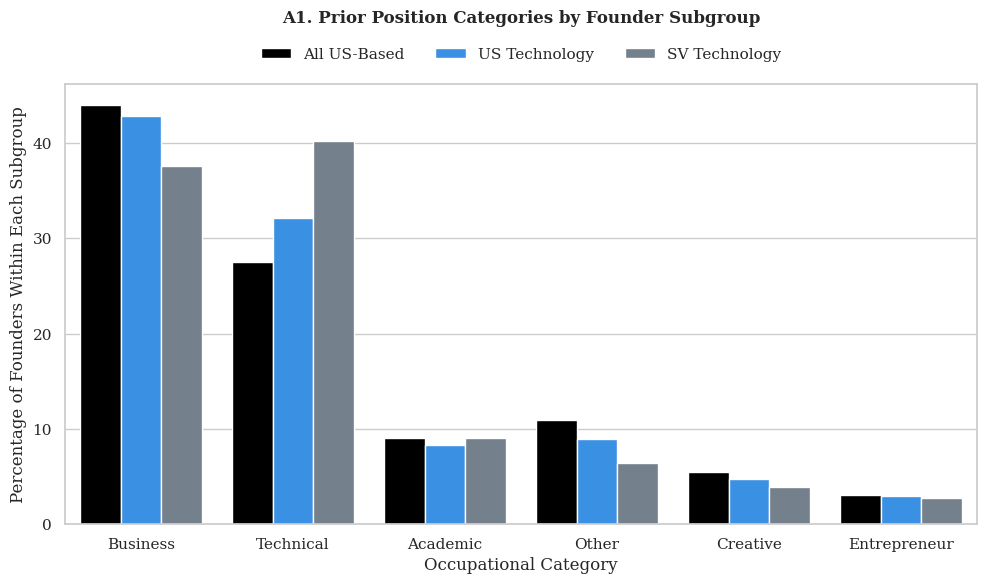

In [7]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Prepare shares data (including technology)
df_shares_long = pd.DataFrame()
for grp, df_grp in [('All US-Based', df_all_us), ('US Technology', df_tech), ('SV Technology', df_sv_tech)]:
    shares = df_grp['prior_role_category'].value_counts(normalize=True).reset_index()
    shares.columns = ['Category', 'Percentage']
    shares['Percentage'] *= 100
    shares['Group'] = grp
    df_shares_long = pd.concat([df_shares_long, shares], ignore_index=True)

cat_order = ['Business', 'Technical', 'Academic', 'Other', 'Creative', 'Entrepreneur']
palette = {'All US-Based': 'black', 'US Technology': 'dodgerblue', 'SV Technology': 'slategrey'}

# Plot 1: Standard Figure 1a
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_shares_long,
    x='Category',
    y='Percentage',
    hue='Group',
    ax=ax,
    palette=palette,
    order=cat_order
)
ax.set_title("A1. Prior Position Categories by Founder Subgroup", y=1.12, fontsize=12, fontweight='bold')
ax.set_xlabel("Occupational Category")
ax.set_ylabel("Percentage of Founders Within Each Subgroup")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, title=None)
plt.tight_layout()

# Save Figure 1a
output_fig_dir = "/Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures"
os.makedirs(output_fig_dir, exist_ok=True)
fig_a_path = os.path.join(output_fig_dir, "Figure_1a.png")
plt.savefig(fig_a_path, dpi=300, bbox_inches='tight')
plt.show()

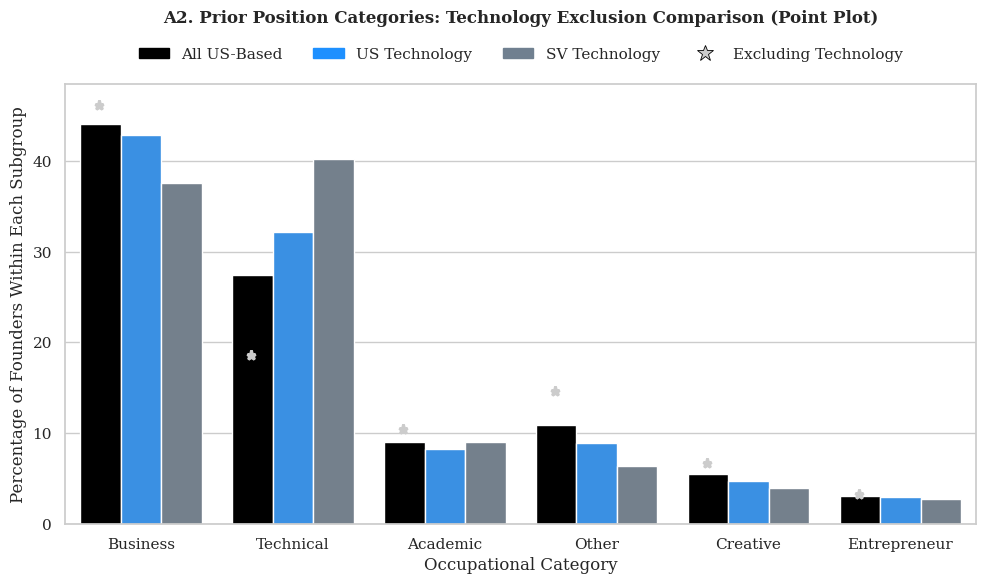

In [8]:
# Plot 2: Technology Comparison Point Plot
df_shares_ex = df_all_us_ex['prior_role_category'].value_counts(normalize=True).reset_index()
df_shares_ex.columns = ['Category', 'Percentage']
df_shares_ex['Percentage'] *= 100
df_shares_ex['Group'] = 'All US-Based'

# Add dummy rows with NaN percentages for 'US Technology' and 'SV Technology' to satisfy Seaborn's dodge calculation (requires unique levels >= 2)
dummy_rows = pd.DataFrame([
    {'Category': 'Business', 'Percentage': np.nan, 'Group': 'US Technology'},
    {'Category': 'Business', 'Percentage': np.nan, 'Group': 'SV Technology'}
])
df_shares_ex_all = pd.concat([df_shares_ex, dummy_rows], ignore_index=True)

fig2, ax2 = plt.subplots(figsize=(10, 6))
# Plot solid bars in background (no opacity)
sns.barplot(
    data=df_shares_long,
    x='Category',
    y='Percentage',
    hue='Group',
    ax=ax2,
    palette=palette,
    order=cat_order
)

# Overlay point plot for Excluding Technology (light grey, '*' shape, dodged to align with 'All US-Based' bar)
sns.pointplot(
    data=df_shares_ex_all,
    x='Category',
    y='Percentage',
    hue='Group',
    ax=ax2,
    palette={'All US-Based': '#cccccc', 'US Technology': '#cccccc', 'SV Technology': '#cccccc'},
    order=cat_order,
    markers='*',
    linestyles='',
    dodge=0.55,
    errorbar=None
)

# Modify the point collection to add a black edge border so the star is visible on both black and white backgrounds
for collection in ax2.collections:
    collection.set_edgecolor('black')
    collection.set_linewidth(0.6)

# Title placed ABOVE the legend
ax2.set_title("A2. Prior Position Categories: Technology Exclusion Comparison (Point Plot)", y=1.12, fontsize=12, fontweight='bold')
ax2.set_xlabel("Occupational Category")
ax2.set_ylabel("Percentage of Founders Within Each Subgroup")

# Custom Legend: no box, no title, located above the plot in 1 single row (ncol=4)
p1 = mpatches.Patch(color='black', label='All US-Based')
p2 = mpatches.Patch(color='dodgerblue', label='US Technology')
p3 = mpatches.Patch(color='slategrey', label='SV Technology')
m2 = mlines.Line2D([], [], color='#cccccc', marker='*', linestyle='', markersize=12, markeredgecolor='black', markeredgewidth=0.6, label='Excluding Technology')

ax2.legend(handles=[p1, p2, p3, m2], loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False, title=None)
plt.tight_layout()
fig_a2_path = os.path.join(output_fig_dir, "Figure_1a_ex_software.png")
plt.savefig(fig_a2_path, dpi=300, bbox_inches='tight')
plt.show()

### Section B: Industry Transition Heatmaps (Prior Industry to Founded Venture Industry)

The following heatmaps capture transition probabilities between founders' prior industries (Y-axis) and founded venture industries (X-axis). All transitions show the row-normalized percentage transition probabilities (i.e. the percentage share of founders from the industry they worked in who founded a venture in each corresponding industry).

The figures are structured with the following layout details to improve alignment and comparison:
- **Color Schemes**: Blacks (Figure 1b - All), Blues (Figure 1b - Technical), and Greys (Figure 1b - Business) colormaps for the heatmaps, with corresponding histogram colors (Black, Dodger Blue, and Slate Grey).
- **Cell Spacing and Perfect Squares**: Shaded cells on each heatmap are separated by a small white space (`linewidths=0.5`) and configured as perfect squares (`square=True`).
- **Percentage Labels**: Every value inside the heatmap is formatted with a percentage sign `%`.
- **Vertical Labels**: Venture industry names on the X-axis are rotated vertically (90 degrees), and the Y-axis prior distribution histogram's title is aligned vertically to the right of the industry names.

/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_98469/3665908914.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = cstab.applymap(lambda v: f"{v:.1f}%")


Saved Figure 1b to: /Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures/Figure_1b.png


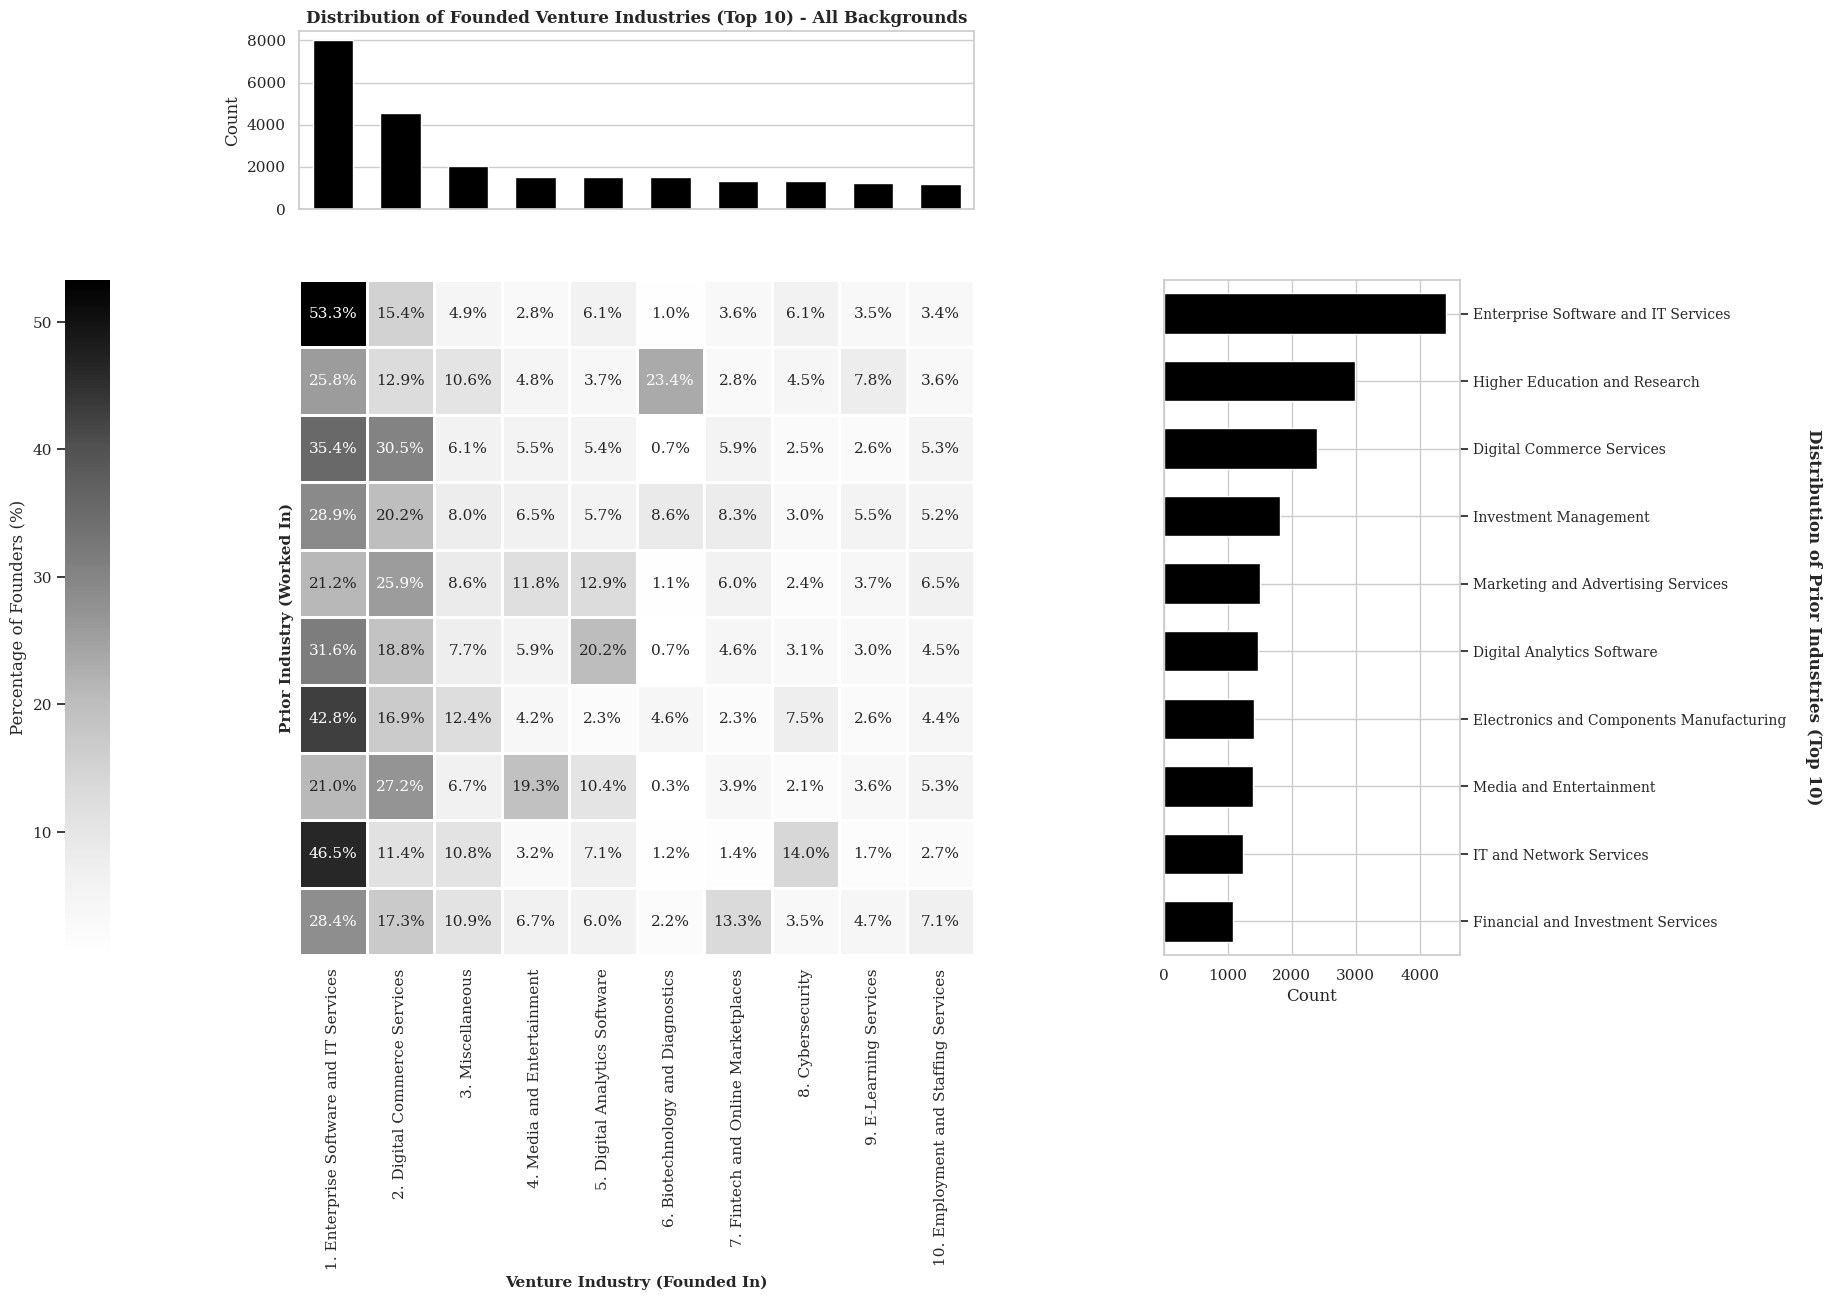

In [9]:
import matplotlib.gridspec as gridspec

# 1. Filter for top 10 industries in prior and venture to keep heatmap readable
df_joint = df_matched_filtered[
    df_matched_filtered['prior_rics_k200'].notnull() &
    df_matched_filtered['venture_rics_k200'].notnull()
].copy()

top_prior_k200 = df_joint['prior_rics_k200'].value_counts().head(10).index.tolist()
top_venture_k200 = df_joint['venture_rics_k200'].value_counts().head(10).index.tolist()

df_joint_sub = df_joint[
    df_joint['prior_rics_k200'].isin(top_prior_k200) &
    df_joint['venture_rics_k200'].isin(top_venture_k200)
].copy()

# Compute row-normalized percentages
cstab = pd.crosstab(
    df_joint_sub['prior_rics_k200'],
    df_joint_sub['venture_rics_k200'],
    normalize='index'
) * 100
cstab = cstab.loc[top_prior_k200, top_venture_k200]

y_labels = top_prior_k200
x_labels = [f"{i+1}. {name}" for i, name in enumerate(top_venture_k200)]
annot_labels = cstab.applymap(lambda v: f"{v:.1f}%")

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(4, 3, hspace=0.4, wspace=0.2, width_ratios=[0.15, 3.0, 1.0])

# Top marginal bar plot (X-distribution) - Black color
ax_top = fig.add_subplot(gs[0, 1])
venture_counts = df_joint['venture_rics_k200'].value_counts().loc[top_venture_k200]
x_positions = [i + 0.5 for i in range(len(top_venture_k200))]
ax_top.bar(x_positions, venture_counts.values, width=0.6, color="black")
ax_top.set_xlim(0, len(top_venture_k200))
ax_top.set_title("Distribution of Founded Venture Industries (Top 10) - All Backgrounds", fontsize=12, fontweight='bold')
ax_top.set_ylabel("Count")
ax_top.xaxis.set_visible(False)

# Colorbar axis on the far left
ax_cbar = fig.add_subplot(gs[1:4, 0])

# Main Heatmap in the middle - Greys (Blacks) colormap, cell spacing, square=True
ax_main = fig.add_subplot(gs[1:4, 1])
sns.heatmap(
    cstab,
    annot=annot_labels,
    fmt="",
    cmap="Greys",
    linewidths=1.0,
    linecolor='white',
    square=True,
    xticklabels=x_labels,
    yticklabels=False,
    cbar=True,
    cbar_ax=ax_cbar,
    cbar_kws={'label': 'Percentage of Founders (%)'},
    ax=ax_main
)
ax_main.set_xlabel("Venture Industry (Founded In)", fontsize=11, fontweight='bold')
ax_main.set_ylabel("Prior Industry (Worked In)", fontsize=11, fontweight='bold')
plt.setp(ax_main.get_xticklabels(), rotation=90, ha='center')

ax_cbar.yaxis.set_ticks_position('left')
ax_cbar.yaxis.set_label_position('left')

# Right marginal bar plot (Y-distribution) - Black color
ax_right = fig.add_subplot(gs[1:4, 2])
prior_counts = df_joint['prior_rics_k200'].value_counts().loc[top_prior_k200]
y_positions = [i + 0.5 for i in range(len(top_prior_k200))]
ax_right.barh(y_positions, prior_counts.values, height=0.6, color="black", align='center')
ax_right.set_ylim(len(top_prior_k200), 0)
ax_right.set_yticks(y_positions)
ax_right.set_yticklabels(y_labels, fontsize=10)
ax_right.yaxis.tick_right()
ax_right.yaxis.set_label_position("right")
ax_right.set_ylabel("Distribution of Prior Industries (Top 10)", rotation=270, labelpad=25, fontsize=12, fontweight='bold')
ax_right.set_xlabel("Count")

# Force draw of canvas to compute correct positions
fig.canvas.draw()
pos = ax_main.get_position()

# Align top and right marginal plots perfectly with the square heatmap bounds
pos_top = ax_top.get_position()
ax_top.set_position([pos.x0, pos_top.y0, pos.width, pos_top.height])

pos_right = ax_right.get_position()
ax_right.set_position([pos_right.x0, pos.y0, pos_right.width, pos.height])

# Save Figure 1b for All Backgrounds
fig_b_path = os.path.join(output_fig_dir, "Figure_1b.png")
plt.savefig(fig_b_path, dpi=300, bbox_inches='tight')
print(f"Saved Figure 1b to: {fig_b_path}")
plt.show()

/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_98469/3033217365.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels_tech = cstab_tech.applymap(lambda v: f"{v:.1f}%")


Saved Technical transition heatmap to: /Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures/Figure_1b_technical.png


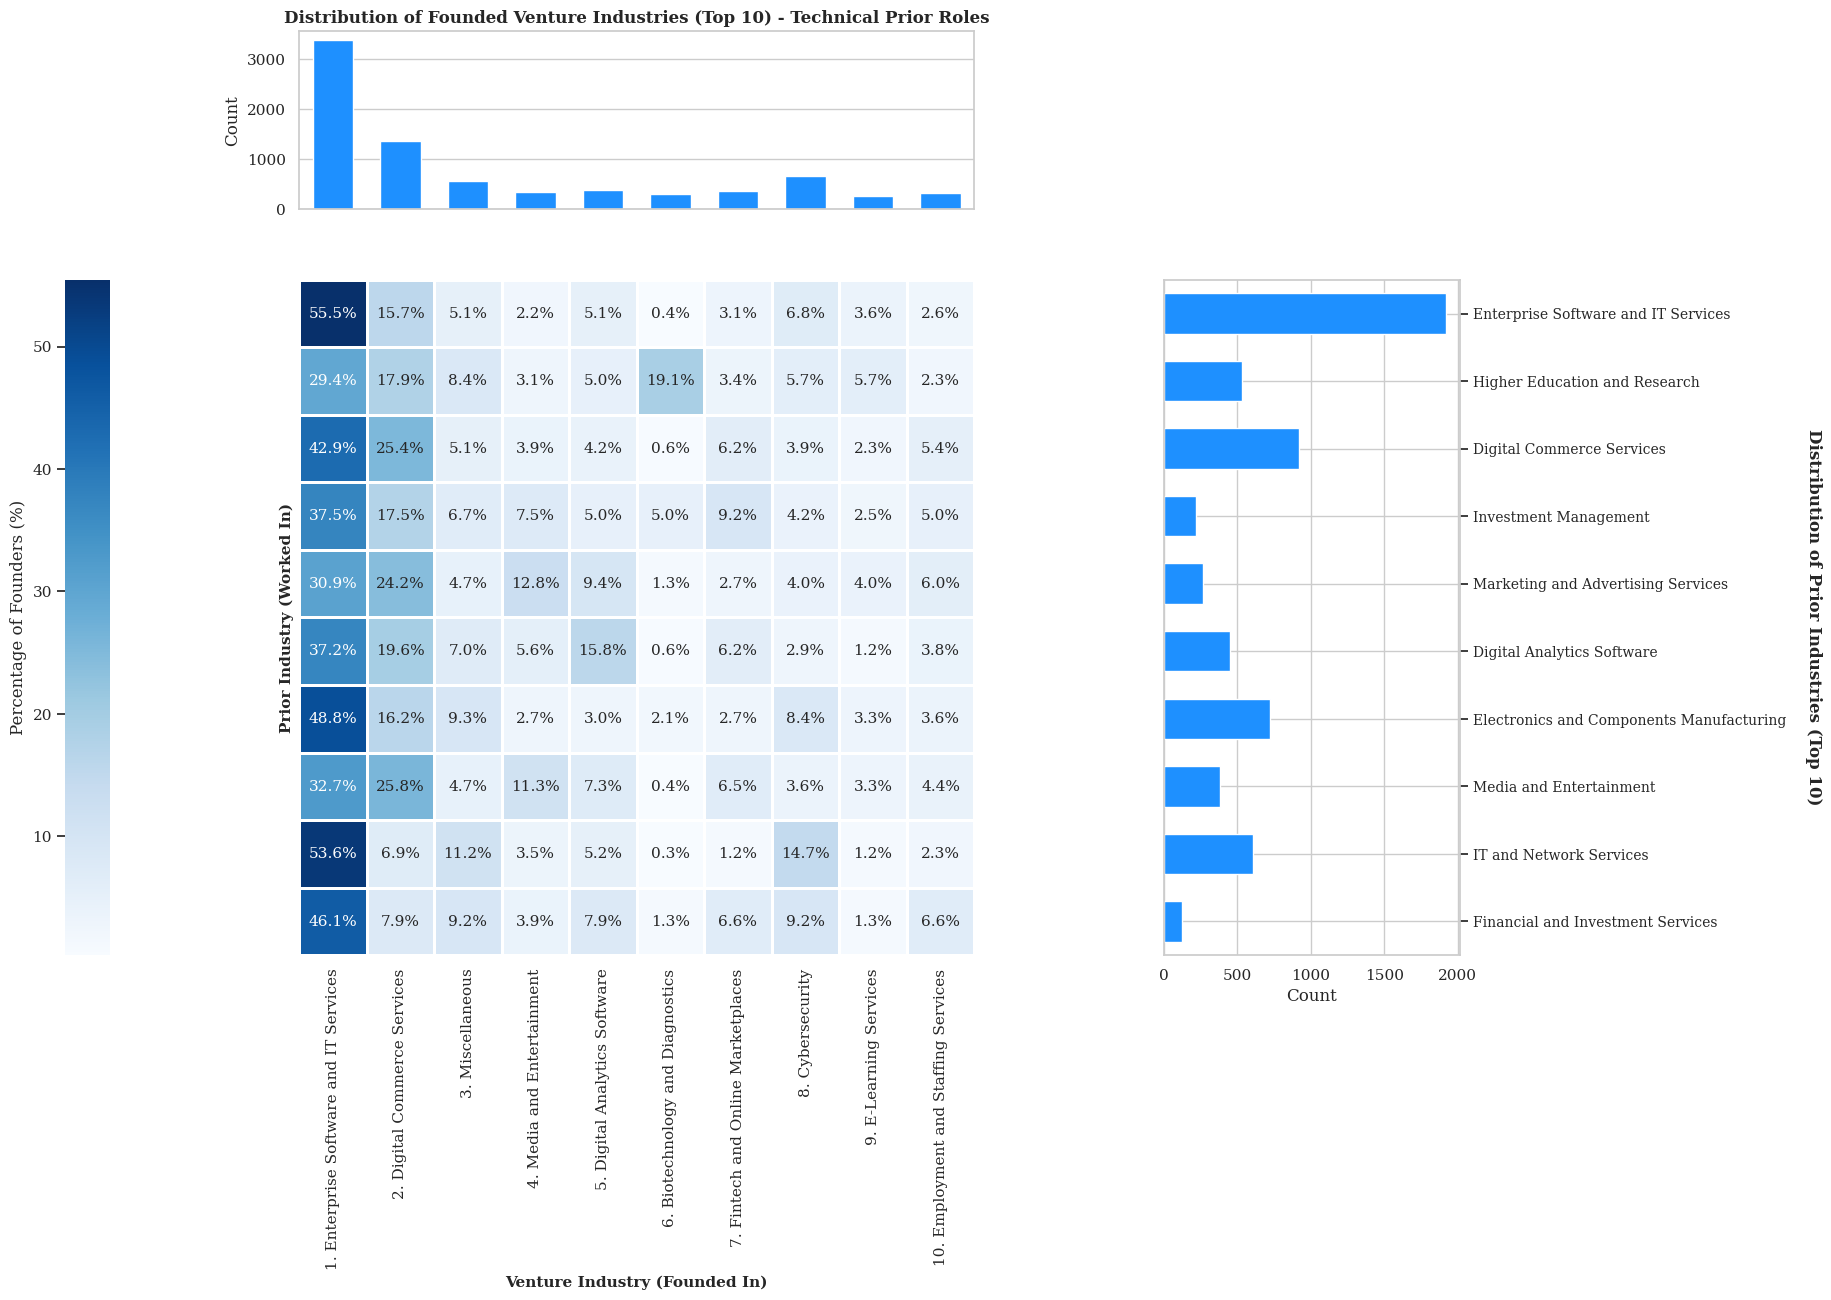

In [10]:
# Plot Heatmap for Technical Backgrounds only - Blues colormap, Dodger Blue histograms, cell spacing, square=True
df_joint_tech = df_joint[df_joint['prior_role_category'] == 'Technical'].copy()

df_joint_sub_tech = df_joint_tech[
    df_joint_tech['prior_rics_k200'].isin(top_prior_k200) &
    df_joint_tech['venture_rics_k200'].isin(top_venture_k200)
].copy()

cstab_tech = pd.crosstab(
    df_joint_sub_tech['prior_rics_k200'],
    df_joint_sub_tech['venture_rics_k200'],
    normalize='index'
) * 100
cstab_tech = cstab_tech.reindex(index=top_prior_k200, columns=top_venture_k200, fill_value=0.0)
annot_labels_tech = cstab_tech.applymap(lambda v: f"{v:.1f}%")

fig_tech = plt.figure(figsize=(18, 12))
gs_tech = gridspec.GridSpec(4, 3, hspace=0.4, wspace=0.2, width_ratios=[0.15, 3.0, 1.0])

# Top marginal bar plot (X-distribution) - Dodger Blue color
ax_top_tech = fig_tech.add_subplot(gs_tech[0, 1])
venture_counts_tech = df_joint_tech['venture_rics_k200'].value_counts().reindex(top_venture_k200, fill_value=0)
ax_top_tech.bar(x_positions, venture_counts_tech.values, width=0.6, color="dodgerblue")
ax_top_tech.set_xlim(0, len(top_venture_k200))
ax_top_tech.set_title("Distribution of Founded Venture Industries (Top 10) - Technical Prior Roles", fontsize=12, fontweight='bold')
ax_top_tech.set_ylabel("Count")
ax_top_tech.xaxis.set_visible(False)

# Colorbar axis
ax_cbar_tech = fig_tech.add_subplot(gs_tech[1:4, 0])

# Main Heatmap - Blues colormap, cell spacing, square=True
ax_main_tech = fig_tech.add_subplot(gs_tech[1:4, 1])
sns.heatmap(
    cstab_tech,
    annot=annot_labels_tech,
    fmt="",
    cmap="Blues",
    linewidths=1.0,
    linecolor='white',
    square=True,
    xticklabels=x_labels,
    yticklabels=False,
    cbar=True,
    cbar_ax=ax_cbar_tech,
    cbar_kws={'label': 'Percentage of Founders (%)'},
    ax=ax_main_tech
)
ax_main_tech.set_xlabel("Venture Industry (Founded In)", fontsize=11, fontweight='bold')
ax_main_tech.set_ylabel("Prior Industry (Worked In)", fontsize=11, fontweight='bold')
plt.setp(ax_main_tech.get_xticklabels(), rotation=90, ha='center')

ax_cbar_tech.yaxis.set_ticks_position('left')
ax_cbar_tech.yaxis.set_label_position('left')

# Right marginal bar plot (Y-distribution) - Dodger Blue color
ax_right_tech = fig_tech.add_subplot(gs_tech[1:4, 2])
prior_counts_tech = df_joint_tech['prior_rics_k200'].value_counts().reindex(top_prior_k200, fill_value=0)
ax_right_tech.barh(y_positions, prior_counts_tech.values, height=0.6, color="dodgerblue", align='center')
ax_right_tech.set_ylim(len(top_prior_k200), 0)
ax_right_tech.set_yticks(y_positions)
ax_right_tech.set_yticklabels(y_labels, fontsize=10)
ax_right_tech.yaxis.tick_right()
ax_right_tech.yaxis.set_label_position("right")
ax_right_tech.set_ylabel("Distribution of Prior Industries (Top 10)", rotation=270, labelpad=25, fontsize=12, fontweight='bold')
ax_right_tech.set_xlabel("Count")

# Perfect alignment bounds
fig_tech.canvas.draw()
pos_t = ax_main_tech.get_position()

pos_top_t = ax_top_tech.get_position()
ax_top_tech.set_position([pos_t.x0, pos_top_t.y0, pos_t.width, pos_top_t.height])

pos_right_t = ax_right_tech.get_position()
ax_right_tech.set_position([pos_right_t.x0, pos_t.y0, pos_right_t.width, pos_t.height])

# Save Figure for Technical
fig_b_tech_path = os.path.join(output_fig_dir, "Figure_1b_technical.png")
plt.savefig(fig_b_tech_path, dpi=300, bbox_inches='tight')
print(f"Saved Technical transition heatmap to: {fig_b_tech_path}")
plt.show()

/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_98469/1664147854.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels_bus = cstab_bus.applymap(lambda v: f"{v:.1f}%")


Saved Business transition heatmap to: /Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures/Figure_1b_business.png


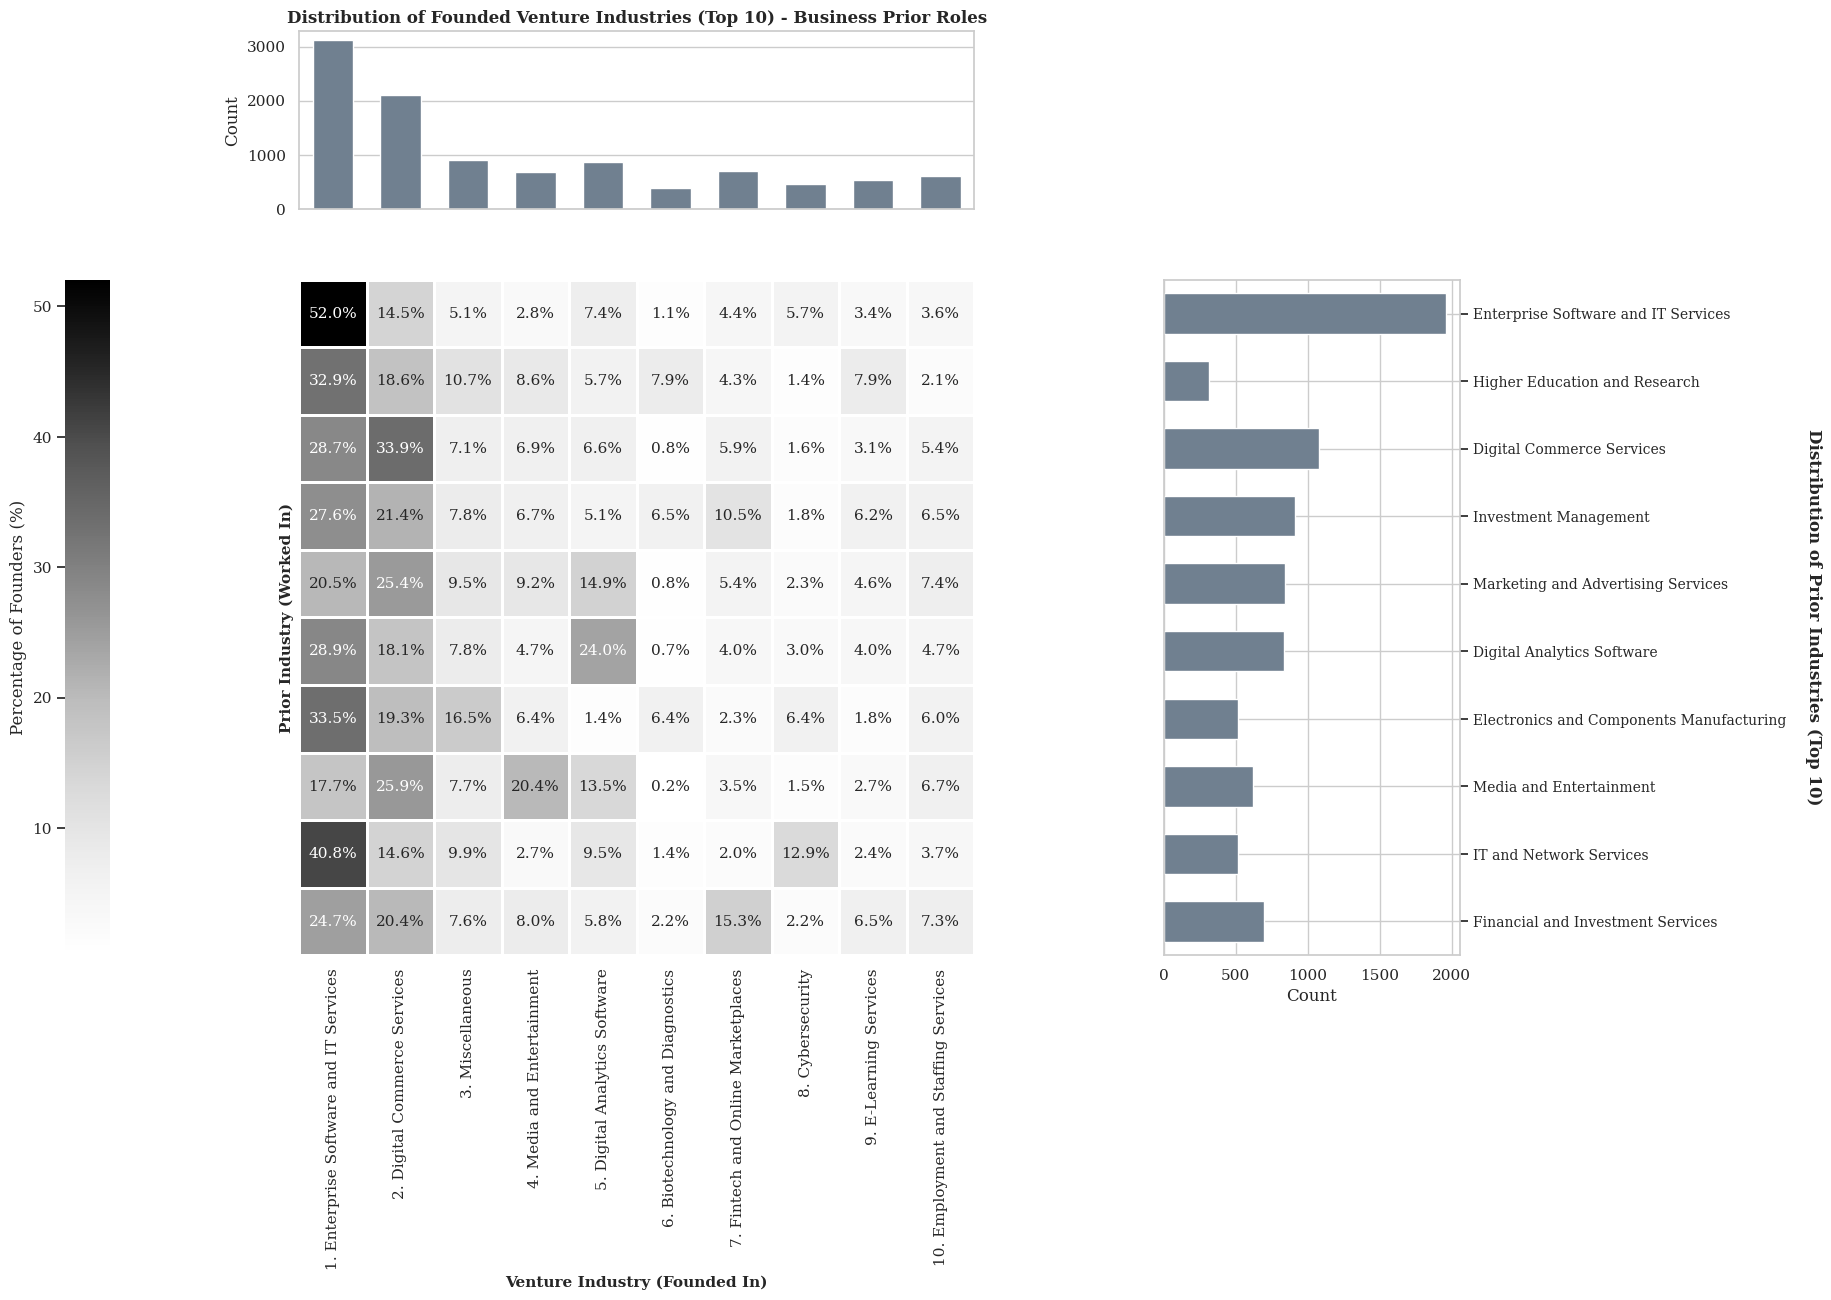

In [11]:
# Plot Heatmap for Business Backgrounds only - Greys colormap, Slate Grey histograms, cell spacing, square=True
df_joint_bus = df_joint[df_joint['prior_role_category'] == 'Business'].copy()

df_joint_sub_bus = df_joint_bus[
    df_joint_bus['prior_rics_k200'].isin(top_prior_k200) &
    df_joint_bus['venture_rics_k200'].isin(top_venture_k200)
].copy()

cstab_bus = pd.crosstab(
    df_joint_sub_bus['prior_rics_k200'],
    df_joint_sub_bus['venture_rics_k200'],
    normalize='index'
) * 100
cstab_bus = cstab_bus.reindex(index=top_prior_k200, columns=top_venture_k200, fill_value=0.0)
annot_labels_bus = cstab_bus.applymap(lambda v: f"{v:.1f}%")

fig_bus = plt.figure(figsize=(18, 12))
gs_bus = gridspec.GridSpec(4, 3, hspace=0.4, wspace=0.2, width_ratios=[0.15, 3.0, 1.0])

# Top marginal bar plot (X-distribution) - Slate Grey color
ax_top_bus = fig_bus.add_subplot(gs_bus[0, 1])
venture_counts_bus = df_joint_bus['venture_rics_k200'].value_counts().reindex(top_venture_k200, fill_value=0)
ax_top_bus.bar(x_positions, venture_counts_bus.values, width=0.6, color="slategrey")
ax_top_bus.set_xlim(0, len(top_venture_k200))
ax_top_bus.set_title("Distribution of Founded Venture Industries (Top 10) - Business Prior Roles", fontsize=12, fontweight='bold')
ax_top_bus.set_ylabel("Count")
ax_top_bus.xaxis.set_visible(False)

# Colorbar axis
ax_cbar_bus = fig_bus.add_subplot(gs_bus[1:4, 0])

# Main Heatmap - Greys colormap, cell spacing, square=True
ax_main_bus = fig_bus.add_subplot(gs_bus[1:4, 1])
sns.heatmap(
    cstab_bus,
    annot=annot_labels_bus,
    fmt="",
    cmap="Greys",
    linewidths=1.0,
    linecolor='white',
    square=True,
    xticklabels=x_labels,
    yticklabels=False,
    cbar=True,
    cbar_ax=ax_cbar_bus,
    cbar_kws={'label': 'Percentage of Founders (%)'},
    ax=ax_main_bus
)
ax_main_bus.set_xlabel("Venture Industry (Founded In)", fontsize=11, fontweight='bold')
ax_main_bus.set_ylabel("Prior Industry (Worked In)", fontsize=11, fontweight='bold')
plt.setp(ax_main_bus.get_xticklabels(), rotation=90, ha='center')

ax_cbar_bus.yaxis.set_ticks_position('left')
ax_cbar_bus.yaxis.set_label_position('left')

# Right marginal bar plot (Y-distribution) - Slate Grey color
ax_right_bus = fig_bus.add_subplot(gs_bus[1:4, 2])
prior_counts_bus = df_joint_bus['prior_rics_k200'].value_counts().reindex(top_prior_k200, fill_value=0)
ax_right_bus.barh(y_positions, prior_counts_bus.values, height=0.6, color="slategrey", align='center')
ax_right_bus.set_ylim(len(top_prior_k200), 0)
ax_right_bus.set_yticks(y_positions)
ax_right_bus.set_yticklabels(y_labels, fontsize=10)
ax_right_bus.yaxis.tick_right()
ax_right_bus.yaxis.set_label_position("right")
ax_right_bus.set_ylabel("Distribution of Prior Industries (Top 10)", rotation=270, labelpad=25, fontsize=12, fontweight='bold')
ax_right_bus.set_xlabel("Count")

# Perfect alignment bounds
fig_bus.canvas.draw()
pos_b = ax_main_bus.get_position()

pos_top_b = ax_top_bus.get_position()
ax_top_bus.set_position([pos_b.x0, pos_top_b.y0, pos_b.width, pos_top_b.height])

pos_right_b = ax_right_bus.get_position()
ax_right_bus.set_position([pos_right_b.x0, pos_b.y0, pos_right_b.width, pos_b.height])

# Save Figure for Business
fig_b_bus_path = os.path.join(output_fig_dir, "Figure_1b_business.png")
plt.savefig(fig_b_bus_path, dpi=300, bbox_inches='tight')
print(f"Saved Business transition heatmap to: {fig_b_bus_path}")
plt.show()

### Section B2: Most Common Roles and Employers Prior to Founding

In this section, we analyze the specific occupational roles (`prior_role_k500_v3`) and employers (`prior_rcid`) that founders held immediately prior to founding their venture.

We match `prior_rcid` with the company names from `RCID_PB_Match.csv` and resolved mappings from the full position list (such as Google, Microsoft, Stanford University, etc.) to get the actual names of the most common pre-founding employers.
We also split the employers to show the most common academic employers as well as the most common industry employers.


In [ ]:
# Analyze the most common pre-founding roles and employers

# 1. Top Roles
top_roles_df = df_matched_filtered['prior_role_k500_v3'].value_counts().head(15).reset_index()
top_roles_df.columns = ['Prior Role (k500)', 'Count']

# 2. Merge prior_rcid to get company name
rcid_to_name_map = {
    350953: 'Microsoft',
    233459: 'Google',
    1400574: 'Cisco Systems',
    22142390: 'IBM',
    237244: 'Stanford University',
    15768159: 'Independent Contractor',
    1146309: 'MIT',
    93225401: 'Independent Contractor',
    297823: 'Yahoo',
    1232095: 'Apple',
    1359692: 'Amazon',
    1311350: 'Intel Corporation',
    1233178: 'Meta / Facebook',
    472640: 'Oracle',
    22142190: 'Dell Technologies',
    22150963: 'McKinsey & Company',
    20937770: 'Deloitte',
    922326: 'UC Berkeley',
    1230770: 'Accenture',
    20923715: 'Goldman Sachs'
}

rcid_pb_match_path = "../../C1 - Data Extraction/Extract Pitchbook Data/RCID_PB_Match.csv"
df_rcid_map = pd.read_csv(rcid_pb_match_path)
rcid_pb_dict = dict(zip(df_rcid_map['rcid'], df_rcid_map['company']))

def resolve_company(rcid_val):
    if pd.isnull(rcid_val):
        return np.nan
    rc_int = int(rcid_val)
    if rc_int in rcid_to_name_map:
        return rcid_to_name_map[rc_int]
    if rc_int in rcid_pb_dict:
        return rcid_pb_dict[rc_int]
    return np.nan

df_matched_filtered['prior_company_resolved'] = df_matched_filtered['prior_rcid'].apply(resolve_company)

# Split by Academic vs Industry
df_academic = df_matched_filtered[df_matched_filtered['prior_role_category'] == 'Academic'].copy()
df_industry = df_matched_filtered[df_matched_filtered['prior_role_category'] != 'Academic'].copy()

top_employers_all = df_matched_filtered['prior_company_resolved'].value_counts().head(15).reset_index()
top_employers_all.columns = ['Employer (All)', 'Count']

top_employers_acad = df_academic['prior_company_resolved'].value_counts().head(10).reset_index()
top_employers_acad.columns = ['Employer (Academic)', 'Count']

top_employers_ind = df_industry['prior_company_resolved'].value_counts().head(10).reset_index()
top_employers_ind.columns = ['Employer (Industry)', 'Count']

# Display side-by-side tables
from IPython.display import display_html
display_html(f'''
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div>
        <h4>Top 15 Prior Roles</h4>
        {top_roles_df.to_html(index=False)}
    </div>
    <div>
        <h4>Top 15 Employers (All)</h4>
        {top_employers_all.to_html(index=False)}
    </div>
    <div>
        <h4>Top 10 Academic Employers</h4>
        {top_employers_acad.to_html(index=False)}
    </div>
    <div>
        <h4>Top 10 Industry Employers</h4>
        {top_employers_ind.to_html(index=False)}
    </div>
</div>
''', raw=True)

# Plot Horizontal Bar Charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=top_roles_df, y='Prior Role (k500)', x='Count', color='dodgerblue', ax=ax1)
ax1.set_title("Top 15 Prior Roles Held by Founders", fontweight='bold')
ax1.set_xlabel("Number of Founders")
ax1.set_ylabel("")

sns.barplot(data=top_employers_all, y='Employer (All)', x='Count', color='black', ax=ax2)
ax2.set_title("Top 15 Prior Employers of Founders", fontweight='bold')
ax2.set_xlabel("Number of Founders")
ax2.set_ylabel("")

plt.tight_layout()
fig_b2_path = os.path.join(output_fig_dir, "Figure_1b2_roles_employers.png")
plt.savefig(fig_b2_path, dpi=300, bbox_inches='tight')
print(f"Saved Figure 1b2 to: {fig_b2_path}")
plt.show()


### Subgroup Definitions:
- **All US-Based Founders**: The full sample of US-based founders whose ventures were founded between 2000 and 2024, have $\le 10$ founders per venture, have a valid platform ID (`venture_firm_id` is non-null and non-zero), and whose ventures lasted for at least one year (`venture_duration_years >= 1`).
- **US Technology Founders**: Founders of ventures in technology industries (defined broadly to include hardware, software, and internet services).
- **Silicon Valley Technology Founders**: Technology founders whose ventures are located in the San Francisco or San Jose metropolitan areas.
- **Software Ventures**: Coded to only capture internet services, software, or AI companies.

### Section C: Founder Age (Years Since First Position) by Occupational Background

The following chart plots the distribution (kernel density estimate) of founder age, measured as the number of years between the founder's first job and the startup's founding year (`years_since_first_job`). We analyze the three major occupational backgrounds:
- **Business Background**: Color coded in **black**.
- **Technical Background**: Color coded in **dodgerblue**.
- **Academic Background**: Color coded in **slategrey**.

Saved age distribution plot to: /Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures/Figure_1c_age_distribution.png


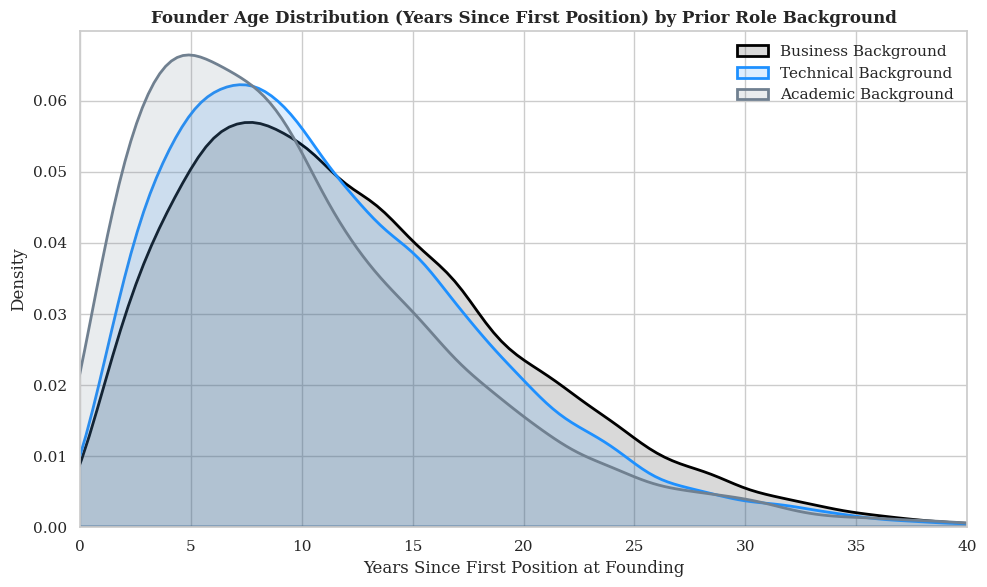

In [12]:
fig_c, ax_c = plt.subplots(figsize=(10, 6))
df_c = df_matched_filtered[df_matched_filtered['prior_role_category'].isin(['Business', 'Technical', 'Academic'])].copy()
df_c = df_c.dropna(subset=['years_since_first_job'])

# Plot KDE distributions for the three occupational categories
sns.kdeplot(data=df_c[df_c['prior_role_category']=='Business'], x='years_since_first_job', color='black', fill=True, alpha=0.15, linewidth=2, label='Business Background', ax=ax_c)
sns.kdeplot(data=df_c[df_c['prior_role_category']=='Technical'], x='years_since_first_job', color='dodgerblue', fill=True, alpha=0.15, linewidth=2, label='Technical Background', ax=ax_c)
sns.kdeplot(data=df_c[df_c['prior_role_category']=='Academic'], x='years_since_first_job', color='slategrey', fill=True, alpha=0.15, linewidth=2, label='Academic Background', ax=ax_c)

ax_c.set_title("Founder Age Distribution (Years Since First Position) by Prior Role Background", fontsize=12, fontweight='bold')
ax_c.set_xlabel("Years Since First Position at Founding")
ax_c.set_ylabel("Density")
ax_c.set_xlim(0, 40)
ax_c.legend(frameon=False)
plt.tight_layout()

fig_c_path = os.path.join(output_fig_dir, "Figure_1c_age_distribution.png")
plt.savefig(fig_c_path, dpi=300, bbox_inches='tight')
print(f"Saved age distribution plot to: {fig_c_path}")
plt.show()

### Section D: Educational Breakdown for Business and Technical Founders

We zoom in on founders who worked in either a **Business** or **Technical** position prior to founding, and classify their educational fields:
- **Business Education**: Founders holding a business major, economics major, or MBA degree (`has_business == 1`, `has_mba == 1`, or `has_econ == 1`).
- **Technical Education**: Founders holding a STEM or Computer Science major (`has_stem == 1` or `has_cs == 1`).

This creates a 2x2 matrix of professional role background by educational background:
1. **Business Position + Business Education** (solid black line)
2. **Business Position + Technical Education** (dashed black line)
3. **Technical Position + Business Education** (solid dodgerblue line)
4. **Technical Position + Technical Education** (dashed dodgerblue line)

Saved education breakdown plot to: /Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures/Figure_1d_education_breakdown.png


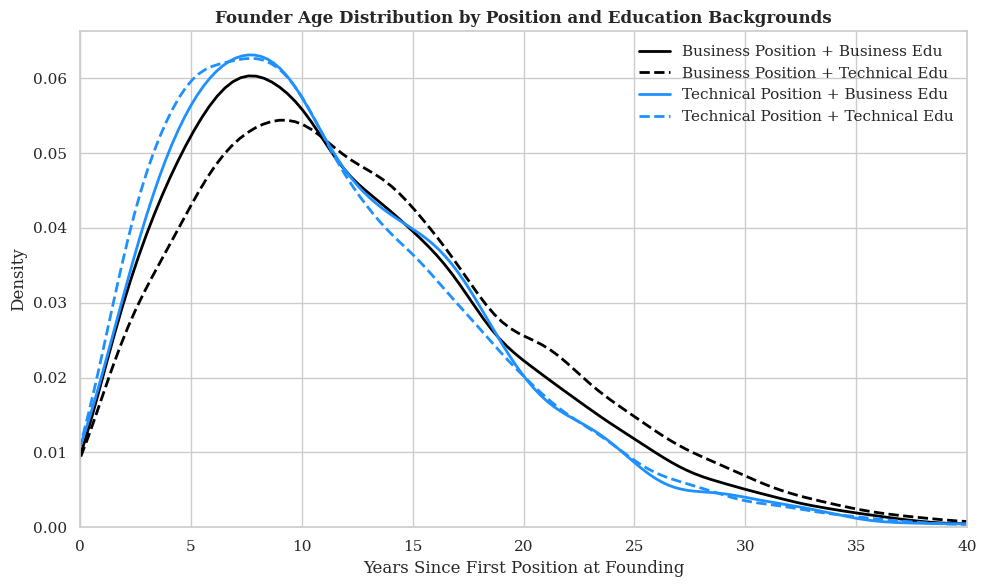

,Subgroup,Count,Mean Experience (Years),Median Experience (Years)
0,Business Position + Business Edu,13088,11.99,10.58
1,Business Position + Technical Edu,7543,13.06,11.84
2,Technical Position + Business Edu,2924,11.35,10.00
3,Technical Position + Technical Edu,10261,11.10,9.75


In [13]:
df_d = df_matched_filtered[df_matched_filtered['prior_role_category'].isin(['Business', 'Technical'])].copy()
df_d['is_business_edu'] = (df_d['has_business'] == 1.0) | (df_d['has_mba'] == 1.0) | (df_d['has_econ'] == 1.0)
df_d['is_tech_edu'] = (df_d['has_stem'] == 1.0) | (df_d['has_cs'] == 1.0)

# Build the 4 groups
g1 = df_d[(df_d['prior_role_category'] == 'Business') & df_d['is_business_edu']].dropna(subset=['years_since_first_job'])
g2 = df_d[(df_d['prior_role_category'] == 'Business') & df_d['is_tech_edu']].dropna(subset=['years_since_first_job'])
g3 = df_d[(df_d['prior_role_category'] == 'Technical') & df_d['is_business_edu']].dropna(subset=['years_since_first_job'])
g4 = df_d[(df_d['prior_role_category'] == 'Technical') & df_d['is_tech_edu']].dropna(subset=['years_since_first_job'])

fig_d, ax_d = plt.subplots(figsize=(10, 6))

# Plot KDE distributions for the educational intersections
sns.kdeplot(data=g1, x='years_since_first_job', color='black', linestyle='-', linewidth=2, label='Business Position + Business Edu', ax=ax_d)
sns.kdeplot(data=g2, x='years_since_first_job', color='black', linestyle='--', linewidth=2, label='Business Position + Technical Edu', ax=ax_d)
sns.kdeplot(data=g3, x='years_since_first_job', color='dodgerblue', linestyle='-', linewidth=2, label='Technical Position + Business Edu', ax=ax_d)
sns.kdeplot(data=g4, x='years_since_first_job', color='dodgerblue', linestyle='--', linewidth=2, label='Technical Position + Technical Edu', ax=ax_d)

ax_d.set_title("Founder Age Distribution by Position and Education Backgrounds", fontsize=12, fontweight='bold')
ax_d.set_xlabel("Years Since First Position at Founding")
ax_d.set_ylabel("Density")
ax_d.set_xlim(0, 40)
ax_d.legend(frameon=False)
plt.tight_layout()

fig_d_path = os.path.join(output_fig_dir, "Figure_1d_education_breakdown.png")
plt.savefig(fig_d_path, dpi=300, bbox_inches='tight')
print(f"Saved education breakdown plot to: {fig_d_path}")
plt.show()

# Print summary table of statistics
summary_data = []
for name, df_grp in [
    ('Business Position + Business Edu', g1),
    ('Business Position + Technical Edu', g2),
    ('Technical Position + Business Edu', g3),
    ('Technical Position + Technical Edu', g4)
]:
    summary_data.append({
        'Subgroup': name,
        'Count': len(df_grp),
        'Mean Experience (Years)': df_grp['years_since_first_job'].mean(),
        'Median Experience (Years)': df_grp['years_since_first_job'].median()
    })

summary_df = pd.DataFrame(summary_data).round(2)
display(summary_df)

### Section E: Analysis of Education and Experience Pairings

In this section, we analyze the intersection of educational background and pre-founding role experience. We focus on the subsample of founders who held either a **Business** or **Technical** position prior to founding (`prior_role_category` is either `'Business'` or `'Technical'`).

We define education and experience categories as:
- **Business Education** (`is_business_edu`): business major, economics major, or MBA degree.
- **Technical Education** (`is_tech_edu`): STEM or CS major.
- **Business Experience** (`has_business_exp`): pre-founding experience in a business role (`exp_role_Business > 0`).
- **Technical Experience** (`has_tech_exp`): pre-founding experience in a technical role (`exp_role_Technical > 0`).

We construct the four non-mutually exclusive pairings (groups):
1. **Business Education & Business Experience**: Founders with business education and business role experience.
2. **Business Education & Technical Experience**: Founders with business education and technical role experience.
3. **Technical Education & Business Experience**: Founders with technical education and business role experience.
4. **Technical Education & Technical Experience**: Founders with technical education and technical role experience.

If a founder has both kinds of education or experience, they are counted in all applicable pairings (both or each). We report the total count of founders in each pairing and plot them in a bar graph.

/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_98469/2537872860.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pairings, x='Pairing', y='Count', palette=colors, ax=ax_e)


Saved pairing counts plot to: /Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures/Figure_1e_pairings.png


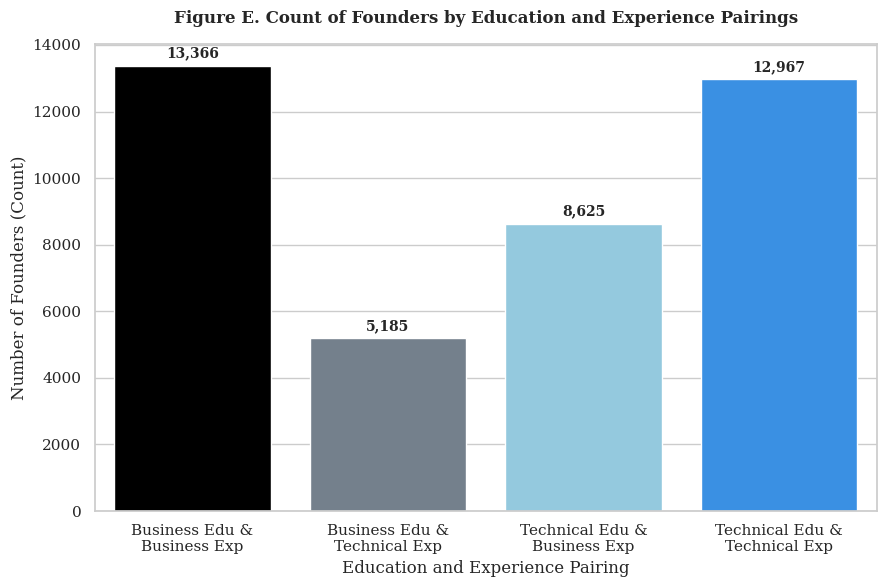

,Pairing,Count
0,Business Edu &\nBusiness Exp,13366
1,Business Edu &\nTechnical Exp,5185
2,Technical Edu &\nBusiness Exp,8625
3,Technical Edu &\nTechnical Exp,12967


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Filter for founders with Business or Technical prior roles
df_e = df_matched_filtered[df_matched_filtered['prior_role_category'].isin(['Business', 'Technical'])].copy()

# Define indicators
df_e['is_business_edu'] = (df_e['has_business'] == 1.0) | (df_e['has_mba'] == 1.0) | (df_e['has_econ'] == 1.0)
df_e['is_tech_edu'] = (df_e['has_stem'] == 1.0) | (df_e['has_cs'] == 1.0)
df_e['has_business_exp'] = df_e['exp_role_Business'] > 0
df_e['has_tech_exp'] = df_e['exp_role_Technical'] > 0

# 2. Calculate counts for the four pairings
pairings = {
    'Business Edu &\nBusiness Exp': len(df_e[df_e['is_business_edu'] & df_e['has_business_exp']]),
    'Business Edu &\nTechnical Exp': len(df_e[df_e['is_business_edu'] & df_e['has_tech_exp']]),
    'Technical Edu &\nBusiness Exp': len(df_e[df_e['is_tech_edu'] & df_e['has_business_exp']]),
    'Technical Edu &\nTechnical Exp': len(df_e[df_e['is_tech_edu'] & df_e['has_tech_exp']])
}

df_pairings = pd.DataFrame(list(pairings.items()), columns=['Pairing', 'Count'])

# Plot Graph E1: Overall pairing counts
fig_e, ax_e = plt.subplots(figsize=(9, 6))
colors = ['black', 'slategrey', 'skyblue', 'dodgerblue']
sns.barplot(data=df_pairings, x='Pairing', y='Count', palette=colors, ax=ax_e)
ax_e.set_title("Figure E. Count of Founders by Education and Experience Pairings", fontsize=12, fontweight='bold', pad=15)
ax_e.set_ylabel("Number of Founders (Count)")
ax_e.set_xlabel("Education and Experience Pairing")

# Add count labels above bars
for p in ax_e.patches:
    height = p.get_height()
    ax_e.annotate(f"{int(height):,}",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 4),  # 4 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
fig_e_path = os.path.join(output_fig_dir, "Figure_1e_pairings.png")
plt.savefig(fig_e_path, dpi=300, bbox_inches='tight')
print(f"Saved pairing counts plot to: {fig_e_path}")
plt.show()

# Print table of statistics
display(df_pairings)

### Section F: Combination of Education and Experience (Career-Long Tenure)

In this section, we analyze the career transition sequences of founders by combining their educational background and the chronological flow of their roles prior to founding.

**Education Type:**
- **Business Edu**: Business/Econ/MBA degree, but NO STEM/CS degree.
- **Tech Edu**: STEM or CS degree, but NO Business/Econ/MBA degree.
- **Tech & Business Edu**: Dual or joint degrees in both fields.
- **Other Edu**: All other educational profiles (humanities, arts, other majors, or no recorded degrees).

**Career Sequence Path:**
We determine the sequence of roles leading up to the founding event using the last role held and prior career experience tenure:
- `Only Business Role`: Last role is Business and has no tech experience. (Sequence: `[Edu] > Business Role > Founder`)
- `Only Tech Role`: Last role is Technical and has no business experience. (Sequence: `[Edu] > Technology Role > Founder`)
- `Tech then Business Role`: Last role is Business and has prior tech experience. (Sequence: `[Edu] > Technology Role > Business Role > Founder`)
- `Business then Tech Role`: Last role is Technical and has prior business experience. (Sequence: `[Edu] > Business Role > Technology Role > Founder`)
- `Other Roles`: Academic, Creative, Entrepreneur, or Other as last role, with prior experience prefixes.

We list out and rank-order all unique sequences in a complete summary table.


In [ ]:
# Analyze career transition sequences and print the rank-ordered list
df_f = df_matched_filtered.copy()

# Classify Education
df_f['is_business_edu'] = (df_f['has_business'] == 1.0) | (df_f['has_mba'] == 1.0) | (df_f['has_econ'] == 1.0)
df_f['is_tech_edu'] = (df_f['has_stem'] == 1.0) | (df_f['has_cs'] == 1.0)

def get_edu_type(row):
    bus = row['is_business_edu']
    tech = row['is_tech_edu']
    if tech and not bus:
        return 'Tech Edu'
    elif bus and not tech:
        return 'Business Edu'
    elif bus and tech:
        return 'Tech & Business Edu'
    else:
        return 'Other Edu'

df_f['edu_type'] = df_f.apply(get_edu_type, axis=1)

# Construct career path sequence
def get_career_sequence(row):
    edu = row['edu_type']
    last_role = row['prior_role_category']
    if pd.isnull(last_role):
        return f'{edu} > Unknown Role > Founder'
    
    has_bus_exp = row['exp_role_Business'] > 0
    has_tech_exp = row['exp_role_Technical'] > 0
    
    if last_role == 'Business':
        if has_tech_exp:
            return f'{edu} > Technology Role > Business Role > Founder'
        else:
            return f'{edu} > Business Role > Founder'
    elif last_role == 'Technical':
        if has_bus_exp:
            return f'{edu} > Business Role > Technology Role > Founder'
        else:
            return f'{edu} > Technology Role > Founder'
    else:
        past = []
        if has_tech_exp:
            past.append('Technology Role')
        if has_bus_exp:
            past.append('Business Role')
        if past:
            past_str = ' & '.join(past)
            return f'{edu} > {past_str} > {last_role} Role > Founder'
        else:
            return f'{edu} > {last_role} Role > Founder'

df_f['career_sequence'] = df_f.apply(get_career_sequence, axis=1)

# Rank order the sequences
seq_counts = df_f['career_sequence'].value_counts().reset_index()
seq_counts.columns = ['Career Transition Sequence', 'Count']
seq_counts['Share (%)'] = (seq_counts['Count'] / len(df_f) * 100).round(2)

print("=== Career Sequence Ranking (All Combinations) ===")
display(seq_counts)


### Section G: Founding Teams Analysis

In this final section, we analyze the structure and composition of founding teams, defined as ventures co-founded by 2 or more individuals in the same year of founding, sharing the same `venture_firm_id` / rcid.

We present a complete analysis including:
1. **Solo Founders backgrounds** vs. **Founding Team Compositions** side-by-side.
2. **Detailed breakdown of the OTHER category** (`Other Combination`), listing out and rank-ordering all of the specific category combinations that fall into this group.


In [ ]:
# Analyze founding teams, solo background, and detailed OTHER breakdown

# 1. Solo vs Team Founders
firm_founders = df_matched_filtered.groupby('venture_firm_id').agg({
    'user_id': 'nunique',
    'prior_role_category': lambda x: sorted(list(x.dropna()))
}).rename(columns={'user_id': 'team_size'})

print('=== Solo vs Team Founded Firms ===')
print(f"Total Firms: {len(firm_founders):,}")
print(f"Solo Founded (1 founder): {(firm_founders['team_size'] == 1).sum():,} ({(firm_founders['team_size'] == 1).mean():.2%})")
print(f"Team Founded (>1 founders): {(firm_founders['team_size'] > 1).sum():,} ({(firm_founders['team_size'] > 1).mean():.2%})")

# 2. Solo Founders Background
solo_firms = firm_founders[firm_founders['team_size'] == 1].copy()
solo_firms['background'] = solo_firms['prior_role_category'].apply(lambda x: x[0] if x else 'Unknown')
solo_bg_counts = solo_firms['background'].value_counts().reset_index()
solo_bg_counts.columns = ['Occupational Background', 'Count']
solo_bg_counts['Share (%)'] = (solo_bg_counts['Count'] / len(solo_firms) * 100).round(2)

# 3. Analyze Team Composition
teams = firm_founders[firm_founders['team_size'] > 1].copy()

def classify_team_composition(categories):
    if not categories:
        return 'Unknown'
    unique_cats = set(categories)
    
    if unique_cats == {'Business'}:
        return 'Business Only'
    if unique_cats == {'Technical'}:
        return 'Technical Only'
    if unique_cats == {'Business', 'Technical'}:
        return 'Technical & Business Only'
    if 'Business' in unique_cats and 'Technical' in unique_cats:
        return 'Technical & Business + Other'
    return 'Other Combination'

teams['composition'] = teams['prior_role_category'].apply(classify_team_composition)
comp_counts = teams['composition'].value_counts().reset_index()
comp_counts.columns = ['Team Composition', 'Count']
comp_counts['Share (%)'] = (comp_counts['Count'] / len(teams) * 100).round(2)

# 4. Detailed OTHER breakdown
other_teams = teams[teams['composition'] == 'Other Combination'].copy()
other_teams['detail'] = other_teams['prior_role_category'].apply(lambda x: ' + '.join(x))
other_breakdown = other_teams['detail'].value_counts().reset_index()
other_breakdown.columns = ['OTHER Background Combination', 'Count']
other_breakdown['Share of OTHER (%)'] = (other_breakdown['Count'] / len(other_teams) * 100).round(2)

print('\n=== Solo Founders Backgrounds ===')
display(solo_bg_counts)
print('\n=== Team Composition Breakdown ===')
display(comp_counts)
print('\n=== Detailed OTHER Breakdown (Top 25) ===')
display(other_breakdown.head(25))

# 5. Plot Solo Backgrounds and Team Compositions Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Solo Backgrounds
sns.barplot(data=solo_bg_counts, x='Occupational Background', y='Count', palette='viridis', ax=ax1, edgecolor='black', linewidth=0.7)
ax1.set_title("Solo Founders' Occupational Backgrounds", fontsize=12, fontweight='bold')
ax1.set_xlabel("Background Category")
ax1.set_ylabel("Number of Firms (Solo)")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15)
for p in ax1.patches:
    height = p.get_height()
    share = height / len(solo_firms) * 100
    ax1.annotate(f"{int(height):,}\n({share:.1f}%)",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')
                
# Plot 2: Team Compositions
sns.barplot(data=comp_counts, x='Team Composition', y='Count', palette='mako', ax=ax2, edgecolor='black', linewidth=0.7)
ax2.set_title("Founding Team Background Compositions", fontsize=12, fontweight='bold')
ax2.set_xlabel("Team Composition Category")
ax2.set_ylabel("Number of Firms (Teams)")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15)
for p in ax2.patches:
    height = p.get_height()
    share = height / len(teams) * 100
    ax2.annotate(f"{int(height):,}\n({share:.1f}%)",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
fig_g_path = os.path.join(output_fig_dir, "Figure_1g_teams.png")
plt.savefig(fig_g_path, dpi=300, bbox_inches='tight')
print(f"Saved team composition plot to: {fig_g_path}")
plt.show()
